# upset2.ipynb — ComplexUpset (R) 版 Upset 图

**与 UpSetR 版的区别**: set size 面板是独立 ggplot2 对象，数轴由用户直接控制，
不再被内部 layout 吞掉。

## 规格
- 数据: 12loc.npy
- 字体: 18pt
- 画布: 8 × 8 英寸
- 刻度: log10
- 色系: 莫兰迪

In [7]:
# ═══════════════════════════════════════
# 1. 环境 & 数据
# ═══════════════════════════════════════
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ComplexUpset, reticulate, Cairo, scales)

# 莫兰迪色系
morandi <- c("#91A3B0", "#B8AD9E", "#957E6E", "#A5A58D", "#6B705C")

# 12 类修饰
mods <- c('Am','Atol','Cm','Gm','Tm','Y','ac4C','m1A','m5C','m6A','m6Am','m7G')

# 加载
np <- import("numpy")
y <- np$load("/home/dc/vscode/vscode20260406/rgcnformer_sum/npy/human3/12loc.npy")
d <- as.data.frame(y)
colnames(d) <- mods

# ComplexUpset 用 logical
d_bool <- as.data.frame(lapply(d, as.logical))

# ── 统计 ──
cat("Set Size:\n")
print(as.data.frame(colSums(d)))

cat("\nIntersections (top 30):\n")
d %>%
  group_by(across(everything())) %>%
  summarise(n = n(), .groups = 'drop') %>%
  filter(rowSums(across(all_of(mods))) > 0) %>%
  arrange(desc(n)) %>%
  head(30) %>%
  as.data.frame() %>%
  print()

Set Size:
     colSums(d)
Am         1935
Atol      49435
Cm         2219
Gm         2196
Tm         2323
Y         36944
ac4C       3925
m1A       15489
m5C        3381
m6A      114195
m6Am       2221
m7G        1508

Intersections (top 30):
   Am Atol Cm Gm Tm Y ac4C m1A m5C m6A m6Am m7G     n
1   0    0  0  0  0 0    0   0   0   1    0   0 84118
2   0    1  0  0  0 0    0   0   0   0    0   0 49435
3   0    0  0  0  0 1    0   0   0   1    0   0 28286
4   0    0  0  0  0 0    0   1   0   0    0   0 15489
5   0    0  0  0  0 1    0   0   0   0    0   0  7055
6   0    0  0  0  0 0    1   0   0   0    0   0  3925
7   0    0  0  0  0 0    0   0   1   0    0   0  3122
8   0    0  0  0  0 0    0   0   0   0    1   0  2221
9   0    0  0  0  1 0    0   0   0   0    0   0  2159
10  0    0  1  0  0 0    0   0   0   0    0   0  1811
11  1    0  0  0  0 0    0   0   0   0    0   0  1536
12  0    0  0  0  0 0    0   0   0   0    0   1  1508
13  0    0  0  1  0 0    0   0   0   0    0   0  1428
1

Warning message in transformation$transform(x):
“NaNs produced”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_segment()`).”


pdf 
  2

Warning message in transformation$transform(x):
“NaNs produced”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_segment()`).”


Done.


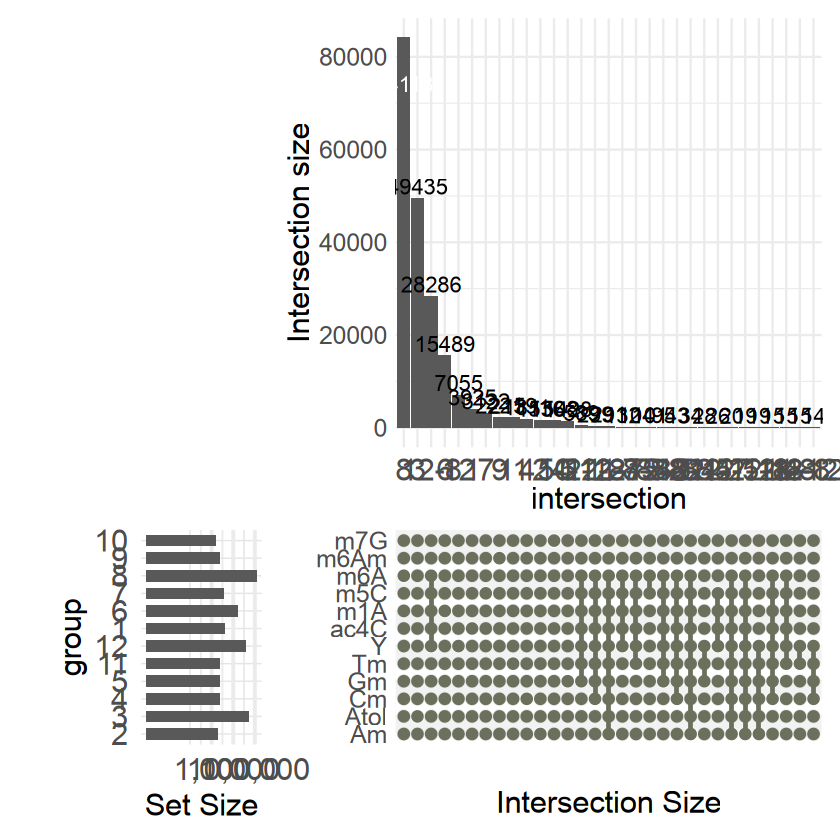

In [8]:
# ═══════════════════════════════════════
# 2. ComplexUpset 绘图
# ═══════════════════════════════════════

p <- upset(
  d_bool,
  mods,
  name          = "Intersection Size",
  width_ratio   = 0.22,
  min_size      = 10,
  min_degree    = 1,
  sort_sets     = FALSE,
  sort_intersections      = "descending",
  sort_intersections_by   = "cardinality",

  # ── set size 面板 (独立 ggplot) ──
  set_sizes = upset_set_size() +
    scale_fill_manual(values = morandi[3], guide = "none") +
    scale_y_log10(
      breaks = c(1e3, 1e4, 1e5),
      labels = scales::label_comma()
    ) +
    ylab("Set Size") +
    theme_minimal(base_size = 18) +
    theme(
      panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
      axis.title.x = element_text(size = 18),
      axis.text.x  = element_text(size = 18),
      axis.text.y  = element_text(size = 18),
      plot.margin   = margin(l = 30, r = 10)
    ),

  # ── 交集柱状图 ──
  base_annotations = list(
    'Intersection size' = intersection_size(
      text = list(size = 4.5)
    ) +
      scale_fill_manual(values = morandi[1], guide = "none") +
      theme(
        axis.text.x  = element_text(size = 18),
        axis.title.x = element_text(size = 18)
      )
  ),

  # ── 矩阵 (点 + 线) ──
  matrix = intersection_matrix(
    geom    = geom_point(size = 2.5, color = morandi[5]),
    segment = geom_segment(color = morandi[5], linewidth = 0.7),
    outline_color = list(active = "white", inactive = "grey90")
  ) +
    theme(
      axis.text.x = element_text(size = 18),
      axis.text.y = element_text(size = 18)
    ),

  themes = upset_default_themes(text = element_text(size = 18))
)

# ── 显示 ──
print(p)

# ── 导出 ──
dir_out <- "/home/dc/vscode/vscode20260603/human_and_plant_few_shot/visualization/human/dataset/fig"
if (!dir.exists(dir_out)) dir.create(dir_out, recursive = TRUE)

# PDF (cairo, AI 可编辑)
Cairo::CairoPDF(file.path(dir_out, "upset2_modifications_AI_ready.pdf"),
               width = 8, height = 8)
print(p)
dev.off()

# PNG
ggsave(file.path(dir_out, "upset2_modifications.png"),
       plot = p, width = 8, height = 8, dpi = 120)

cat("Done.\n")